In [1]:
# ============================================================
# Cell 1 — Imports & Load Data
# ============================================================

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import time
import os

os.makedirs("output_files", exist_ok=True)

nodes_df = pd.read_csv("malleshwaram_nodes.csv")
edges_df = pd.read_csv("malleshwaram_edges.csv")

print(f"Nodes : {len(nodes_df)}")
print(f"Edges : {len(edges_df)}")
print(f"Edge cost column stats (distance_meters):")
print(edges_df["distance_meters"].describe())

Nodes : 2392
Edges : 6728
Edge cost column stats (distance_meters):
count    6728.000000
mean       58.134188
std        46.796981
min         1.152830
25%        29.841993
50%        43.689039
75%        76.913128
max       810.620295
Name: distance_meters, dtype: float64


In [2]:
# ============================================================
# Cell 2 — Build Graph
# Cost = distance_meters (₹1 per meter)
# ============================================================

G = nx.Graph()

for _, row in nodes_df.iterrows():
    G.add_node(int(row['node_id']),
               x=row['longitude'],
               y=row['latitude'])

# Keep cheapest edge between duplicate (u,v) pairs
for _, row in edges_df.iterrows():
    u = int(row['source'])
    v = int(row['target'])
    cost = float(row['distance_meters'])
    if G.has_edge(u, v):
        if cost < G[u][v]['cost']:
            G[u][v]['cost'] = cost
    else:
        G.add_edge(u, v, cost=cost)

pos = {node: (data['x'], data['y']) for node, data in G.nodes(data=True)}

total_cost_all = sum(d['cost'] for _, _, d in G.edges(data=True))

print(f"Graph  : {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Total edge cost : ₹{total_cost_all:,.0f} m")

Graph  : 2392 nodes, 3581 edges
Total edge cost : ₹212,314 m


In [3]:
# ============================================================
# Cell 3 — Budget Setup
# MST cost = minimum to connect everything = natural lower bound.
# We test at 30%, 50%, 70% of MST cost so the constraint is tight.
# ============================================================

mst_ref = nx.minimum_spanning_tree(G, weight='cost', algorithm='kruskal')
MST_COST = sum(G[u][v]['cost'] for u, v in mst_ref.edges())

print(f"MST cost (min to connect all) : ₹{MST_COST:,.0f} m")

BUDGET = int(MST_COST * 0.50)   # ← change this fraction to experiment
print(f"Budget set to 50% of MST cost : ₹{BUDGET:,.0f} m")

BUDGET_FRACS = [0.20, 0.35, 0.50, 0.65, 0.80]

MST cost (min to connect all) : ₹93,877 m
Budget set to 50% of MST cost : ₹46,938 m


In [4]:
# ============================================================
# Cell 4 — Shared utilities: UnionFind + connected_pairs
# ============================================================

class UnionFind:
    def __init__(self, nodes):
        self.parent = {n: n for n in nodes}
        self.rank   = {n: 0 for n in nodes}
        self.size   = {n: 1 for n in nodes}

    def find(self, x):
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]
            x = self.parent[x]
        return x

    def union(self, x, y):
        rx, ry = self.find(x), self.find(y)
        if rx == ry:
            return False
        if self.rank[rx] < self.rank[ry]:
            rx, ry = ry, rx
        self.parent[ry] = rx
        self.size[rx] += self.size[ry]
        if self.rank[rx] == self.rank[ry]:
            self.rank[rx] += 1
        return True


def connected_pairs(G_ref, selected_edges):
    """Count reachable unordered pairs in the subgraph of selected_edges."""
    H = nx.Graph()
    H.add_nodes_from(G_ref.nodes())
    H.add_edges_from(selected_edges)
    return sum(len(c) * (len(c) - 1) // 2
               for c in nx.connected_components(H))


print("UnionFind and connected_pairs ready.")

UnionFind and connected_pairs ready.


In [5]:
# ============================================================
# Cell 5 — Greedy 1: Cheapest-first, NO cycle check
# Flaw: wastes budget on redundant edges inside dense clusters.
# ============================================================

def greedy1_no_cycle_check(G, budget):
    edges_sorted = sorted(G.edges(data=True), key=lambda e: e[2]['cost'])
    selected = []
    spent = 0.0
    for u, v, d in edges_sorted:
        if spent + d['cost'] <= budget:
            selected.append((u, v))
            spent += d['cost']
    return selected, spent


t0 = time.perf_counter()
g1_edges, g1_spent = greedy1_no_cycle_check(G, BUDGET)
t_g1 = time.perf_counter() - t0

g1_pairs = connected_pairs(G, g1_edges)

print("=== Greedy 1: Cheapest-first, No Cycle Check ===")
print(f"Edges selected : {len(g1_edges)}")
print(f"Budget used    : ₹{g1_spent:,.0f} / ₹{BUDGET:,.0f}")
print(f"Connected pairs: {g1_pairs:,}")
print(f"Time           : {t_g1*1000:.3f} ms")

=== Greedy 1: Cheapest-first, No Cycle Check ===
Edges selected : 1728
Budget used    : ₹46,926 / ₹46,938
Connected pairs: 27,773
Time           : 3.440 ms


In [6]:
# ============================================================
# Cell 6 — Greedy 2: Cheapest-first, WITH cycle check
# Flaw: cost alone doesn't account for connectivity gain.
# A cheap intra-cluster edge beats a pricier cross-component bridge.
# ============================================================

def greedy2_with_cycle_check(G, budget):
    edges_sorted = sorted(G.edges(data=True), key=lambda e: e[2]['cost'])
    uf = UnionFind(G.nodes())
    selected = []
    spent = 0.0
    for u, v, d in edges_sorted:
        if uf.find(u) == uf.find(v):
            continue                      # skip cycles
        if spent + d['cost'] <= budget:
            uf.union(u, v)
            selected.append((u, v))
            spent += d['cost']
    return selected, spent


t0 = time.perf_counter()
g2_edges, g2_spent = greedy2_with_cycle_check(G, BUDGET)
t_g2 = time.perf_counter() - t0

g2_pairs = connected_pairs(G, g2_edges)

print("=== Greedy 2: Cheapest-first, With Cycle Check ===")
print(f"Edges selected : {len(g2_edges)}")
print(f"Budget used    : ₹{g2_spent:,.0f} / ₹{BUDGET:,.0f}")
print(f"Connected pairs: {g2_pairs:,}")
print(f"Time           : {t_g2*1000:.3f} ms")

=== Greedy 2: Cheapest-first, With Cycle Check ===
Edges selected : 1705
Budget used    : ₹46,934 / ₹46,938
Connected pairs: 43,691
Time           : 8.633 ms


In [7]:
# ============================================================
# Cell 7 — Greedy 3: Max ρ = Δf / w(e), recomputed each step
# Δf = size_A × size_B for a bridge between components A and B.
# Flaw: myopic — but empirically strongest greedy on real networks.
# ============================================================

def greedy3_max_rho(G, budget):
    uf  = UnionFind(G.nodes())
    rem = list(G.edges(data=True))
    selected = []
    spent = 0.0

    while True:
        best_rho  = -1
        best_edge = None

        for u, v, d in rem:
            ru, rv = uf.find(u), uf.find(v)
            if ru == rv:
                continue                   # cycle → Δf = 0
            if spent + d['cost'] > budget:
                continue                   # over budget
            rho = (uf.size[ru] * uf.size[rv]) / d['cost']
            if rho > best_rho:
                best_rho  = rho
                best_edge = (u, v, d)

        if best_edge is None:
            break

        u, v, d = best_edge
        uf.union(u, v)
        selected.append((u, v))
        spent += d['cost']

    return selected, spent


t0 = time.perf_counter()
g3_edges, g3_spent = greedy3_max_rho(G, BUDGET)
t_g3 = time.perf_counter() - t0

g3_pairs = connected_pairs(G, g3_edges)

print("=== Greedy 3: Max ρ = Δf / w(e) ===")
print(f"Edges selected : {len(g3_edges)}")
print(f"Budget used    : ₹{g3_spent:,.0f} / ₹{BUDGET:,.0f}")
print(f"Connected pairs: {g3_pairs:,}")
print(f"Time           : {t_g3*1000:.3f} ms")

=== Greedy 3: Max ρ = Δf / w(e) ===
Edges selected : 1262
Budget used    : ₹46,934 / ₹46,938
Connected pairs: 759,564
Time           : 1107.019 ms


In [8]:
# ============================================================
# Cell 8 — Summary Table
# ============================================================

n = G.number_of_nodes()
max_pairs = n * (n - 1) // 2

print(f"Budget = ₹{BUDGET:,}   |   Nodes = {n}   |   Max possible pairs = {max_pairs:,}")
print()
print(f"{'Algorithm':<35} {'Pairs':>10} {'Budget used':>14} {'Time (ms)':>10}")
print("-" * 75)

rows = [
    ("Greedy 1 (no cycle check)",  g1_pairs, g1_spent, t_g1),
    ("Greedy 2 (cycle check)",     g2_pairs, g2_spent, t_g2),
    ("Greedy 3 (max ρ)",           g3_pairs, g3_spent, t_g3),
]

for name, pairs, spent, t in rows:
    print(f"{name:<35} {pairs:>10,} {spent:>14,.0f} {t*1000:>10.3f}")

Budget = ₹46,938   |   Nodes = 2392   |   Max possible pairs = 2,859,636

Algorithm                                Pairs    Budget used  Time (ms)
---------------------------------------------------------------------------
Greedy 1 (no cycle check)               27,773         46,926      3.440
Greedy 2 (cycle check)                  43,691         46,934      8.633
Greedy 3 (max ρ)                       759,564         46,934   1107.019


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/networkx/drawing/nx_pylab.py:1497: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  node_collection = ax.scatter(


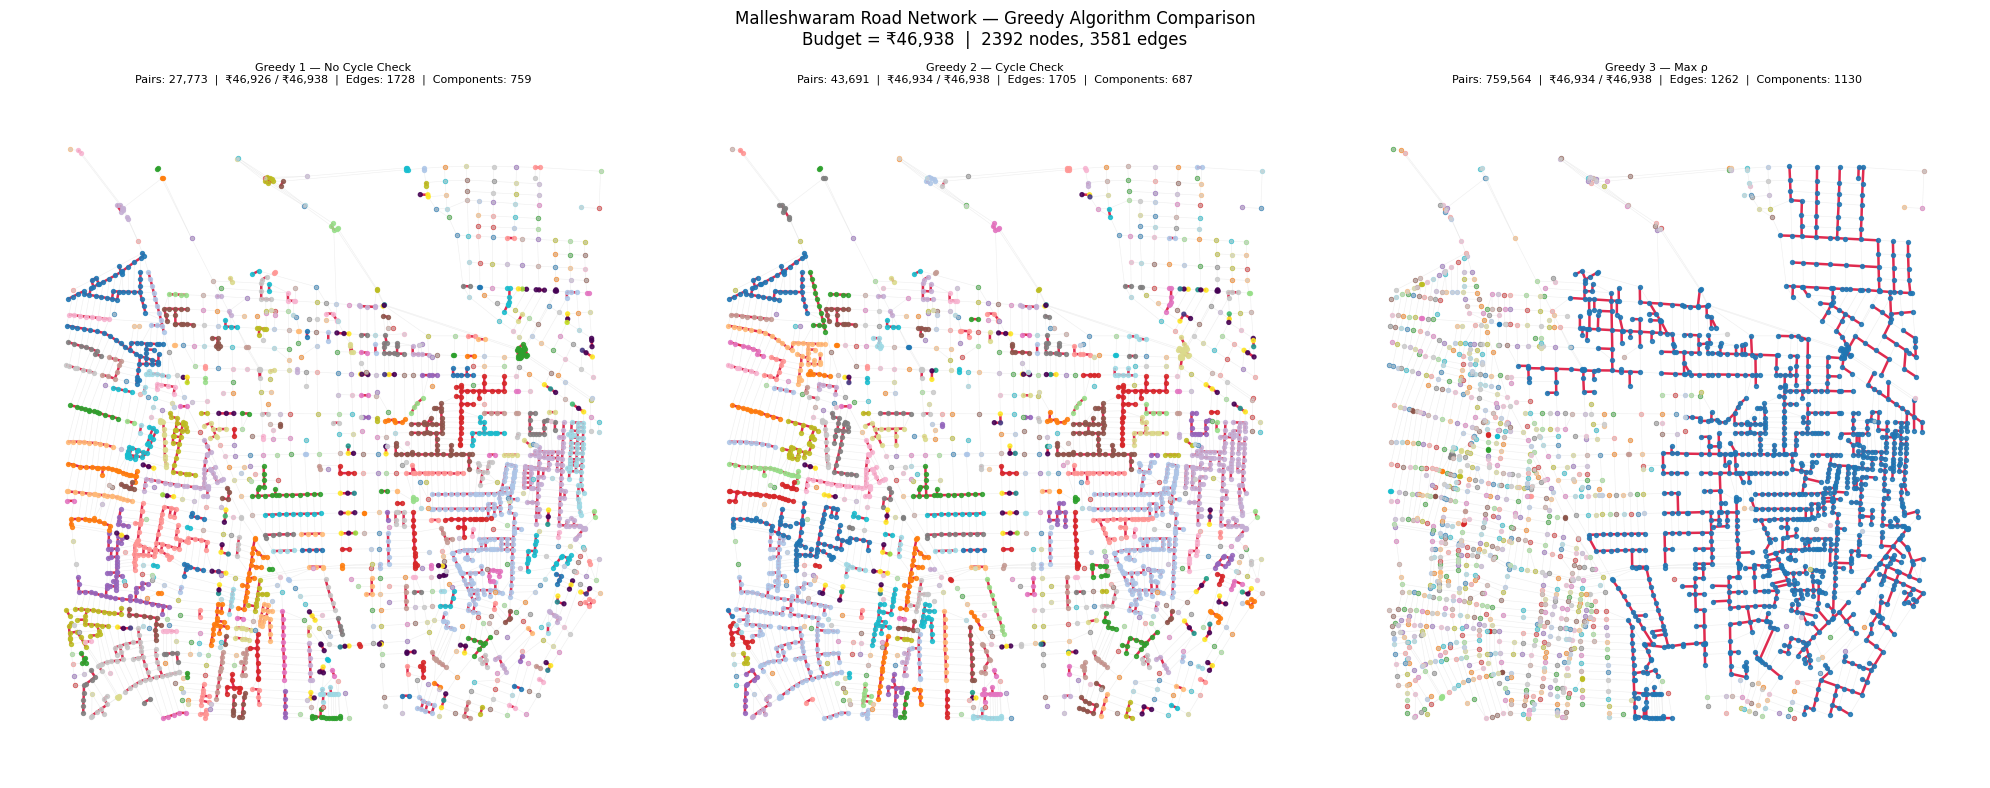

Saved: output_files/malleshwaram_greedy_comparison.png


In [9]:
# ============================================================
# Cell 9 — Plot: Network maps for all 3 greedy approaches
# ============================================================

def draw_osm_result(ax, G, pos, selected_edges, title, spent, budget, pairs):
    sel_set = set(map(lambda e: tuple(sorted(e)), selected_edges))
    unsel   = [(u, v) for u, v in G.edges()
               if tuple(sorted((u, v))) not in sel_set]

    H = nx.Graph()
    H.add_nodes_from(G.nodes())
    H.add_edges_from(selected_edges)
    comps   = list(nx.connected_components(H))
    palette = plt.cm.tab20.colors

    # Unselected edges (faint)
    nx.draw_networkx_edges(G, pos, edgelist=unsel,
                           edge_color='#dddddd', width=0.4, alpha=0.5, ax=ax)

    # Selected edges
    nx.draw_networkx_edges(H, pos, edgelist=selected_edges,
                           edge_color='crimson', width=1.8, alpha=0.9, ax=ax)

    # Nodes coloured by component
    for idx, comp in enumerate(comps):
        nx.draw_networkx_nodes(G, pos, nodelist=list(comp),
                               node_color=palette[idx % len(palette)],
                               node_size=8, alpha=0.85, ax=ax)

    # Isolated nodes
    isolated = [n for n in G.nodes() if H.degree(n) == 0]
    if isolated:
        nx.draw_networkx_nodes(G, pos, nodelist=isolated,
                               node_color='lightgray', node_size=5,
                               alpha=0.5, ax=ax)

    ax.set_title(
        f"{title}\n"
        f"Pairs: {pairs:,}  |  ₹{spent:,.0f} / ₹{budget:,}  |  "
        f"Edges: {len(selected_edges)}  |  Components: {len(comps)}",
        fontsize=8
    )
    ax.axis('off')


fig, axes = plt.subplots(1, 3, figsize=(20, 8))

draw_osm_result(axes[0], G, pos, g1_edges,
                "Greedy 1 — No Cycle Check", g1_spent, BUDGET, g1_pairs)
draw_osm_result(axes[1], G, pos, g2_edges,
                "Greedy 2 — Cycle Check",    g2_spent, BUDGET, g2_pairs)
draw_osm_result(axes[2], G, pos, g3_edges,
                "Greedy 3 — Max ρ",          g3_spent, BUDGET, g3_pairs)

plt.suptitle(
    f"Malleshwaram Road Network — Greedy Algorithm Comparison\n"
    f"Budget = ₹{BUDGET:,}  |  {G.number_of_nodes()} nodes, "
    f"{G.number_of_edges()} edges",
    fontsize=12
)
plt.tight_layout()
plt.savefig("output_files/malleshwaram_greedy_comparison.png", dpi=200, bbox_inches='tight')
plt.show()
print("Saved: output_files/malleshwaram_greedy_comparison.png")

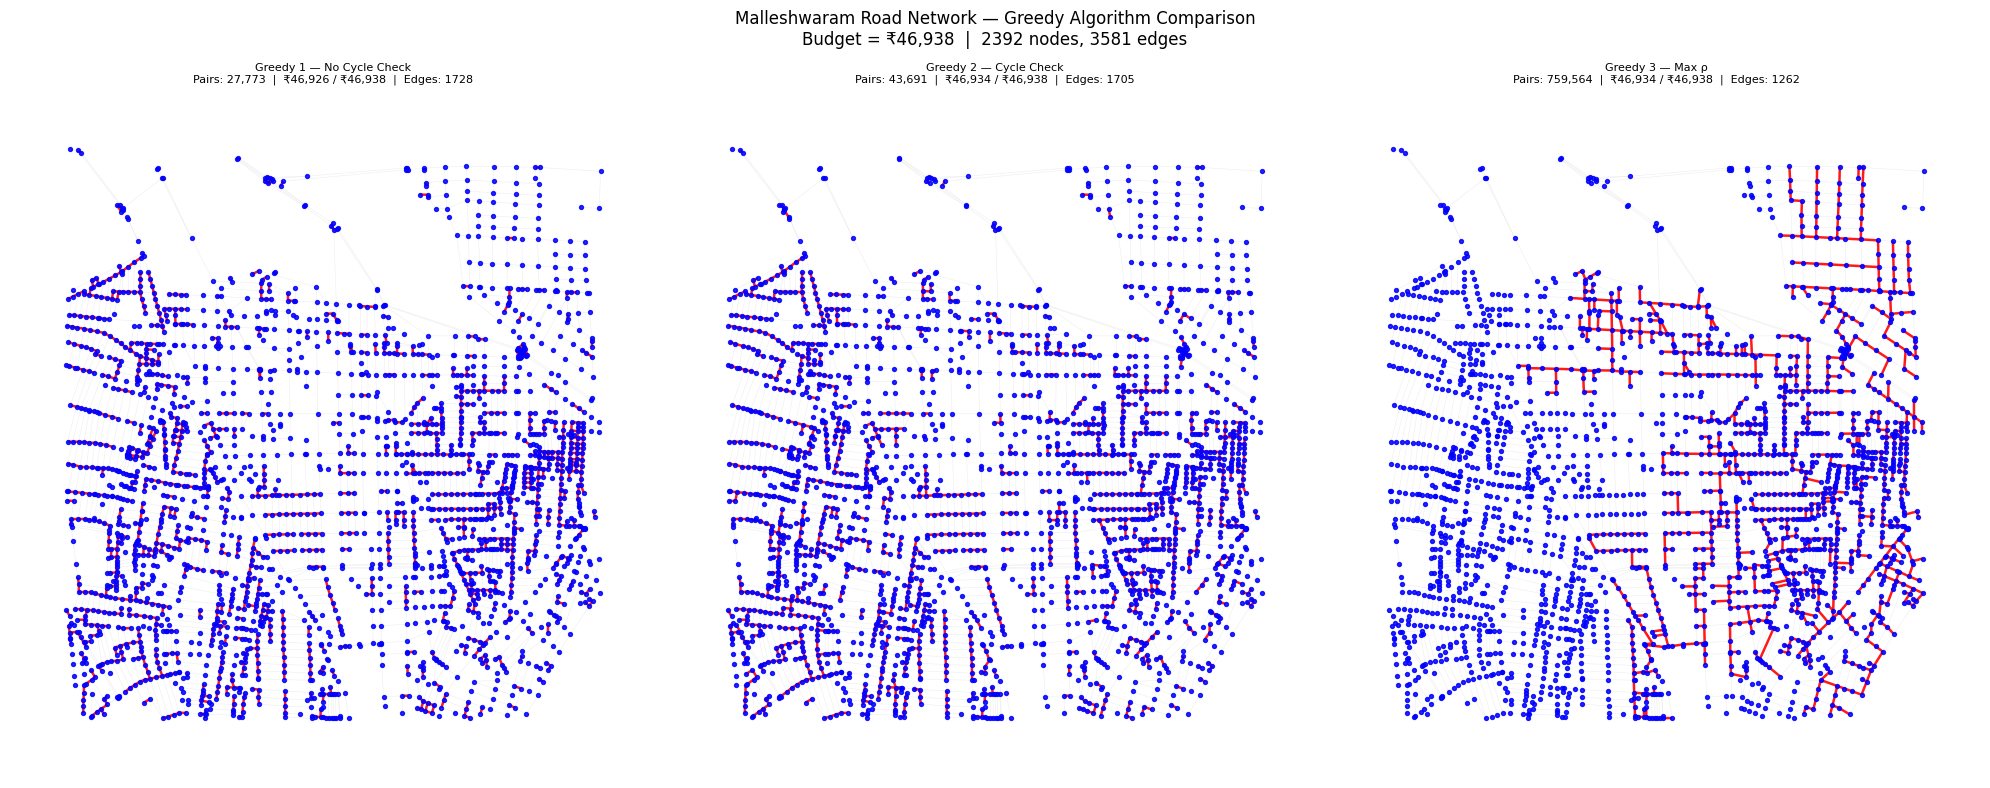

Saved: output_files/malleshwaram_greedy_comparison_same_colour.png


In [12]:
# ============================================================
# Cell 9 — Plot: Network maps for all 3 greedy approaches- same colour
# ============================================================

def draw_osm_result_same_colour(ax, G, pos, selected_edges, title, spent, budget, pairs):
    sel_set = set(map(lambda e: tuple(sorted(e)), selected_edges))
    unsel   = [(u, v) for u, v in G.edges()
               if tuple(sorted((u, v))) not in sel_set]

    # Draw unselected edges (faint gray)
    nx.draw_networkx_edges(
        G, pos, edgelist=unsel,
        edge_color='#dddddd', width=0.4, alpha=0.5, ax=ax
    )

    # Draw selected edges (red)
    nx.draw_networkx_edges(
        G, pos, edgelist=selected_edges,
        edge_color='red', width=1.8, alpha=0.9, ax=ax
    )

    # Draw ALL nodes in blue
    nx.draw_networkx_nodes(
        G, pos,
        node_color='blue',
        node_size=8,
        alpha=0.85,
        ax=ax
    )

    ax.set_title(
        f"{title}\n"
        f"Pairs: {pairs:,}  |  ₹{spent:,.0f} / ₹{budget:,}  |  "
        f"Edges: {len(selected_edges)}",
        fontsize=8
    )
    ax.axis('off')



fig, axes = plt.subplots(1, 3, figsize=(20, 8))

draw_osm_result_same_colour(axes[0], G, pos, g1_edges,
                "Greedy 1 — No Cycle Check", g1_spent, BUDGET, g1_pairs)
draw_osm_result_same_colour(axes[1], G, pos, g2_edges,
                "Greedy 2 — Cycle Check",    g2_spent, BUDGET, g2_pairs)
draw_osm_result_same_colour(axes[2], G, pos, g3_edges,
                "Greedy 3 — Max ρ",          g3_spent, BUDGET, g3_pairs)

plt.suptitle(
    f"Malleshwaram Road Network — Greedy Algorithm Comparison\n"
    f"Budget = ₹{BUDGET:,}  |  {G.number_of_nodes()} nodes, "
    f"{G.number_of_edges()} edges",
    fontsize=12
)
plt.tight_layout()
plt.savefig("output_files/malleshwaram_greedy_comparison.png", dpi=200, bbox_inches='tight')
plt.show()
print("Saved: output_files/malleshwaram_greedy_comparison_same_colour.png")

    Budget   Frac        G1        G2        G3
--------------------------------------------------
₹   18,775    20%     2,843     2,989   189,467
₹   32,857    35%     9,606    11,942   445,136
₹   46,938    50%    27,773    43,691   759,564
₹   61,020    65%   111,822   195,071  1,172,775
₹   75,101    80%   231,249   494,420  1,973,106

Saved: output_files/malleshwaram_budget_sweep.csv


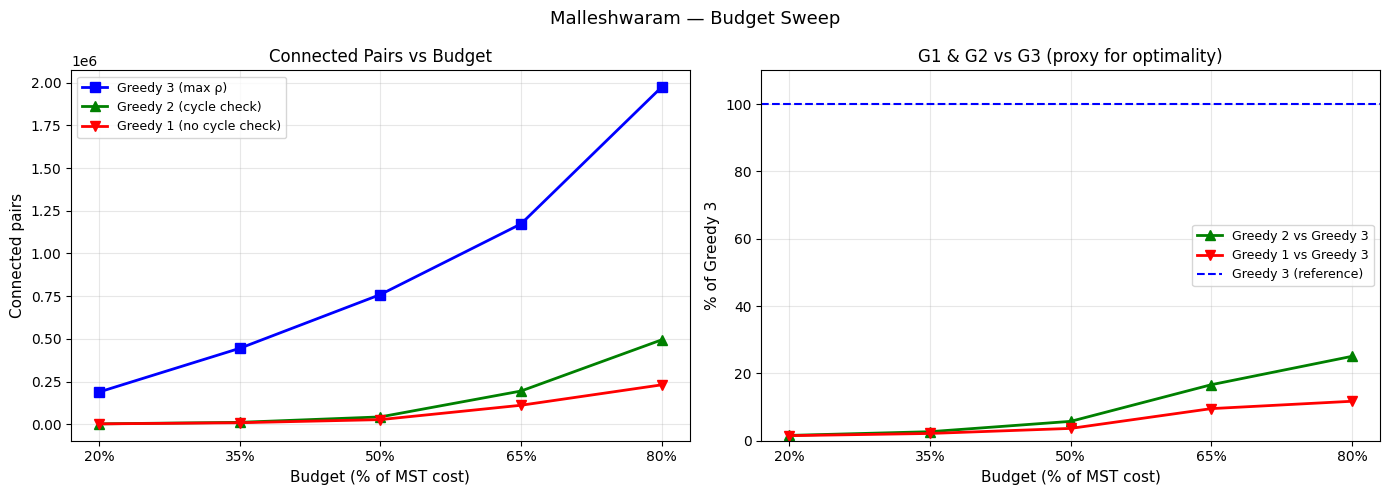

Saved: output_files/malleshwaram_budget_sweep.png


In [10]:
# ============================================================
# Cell 10 — Budget sweep across 5 levels, save CSV + plot
# ============================================================

budgets = [int(MST_COST * f) for f in BUDGET_FRACS]
sweep = {"G1": [], "G2": [], "G3": []}

print(f"{'Budget':>10} {'Frac':>6}  {'G1':>8}  {'G2':>8}  {'G3':>8}")
print("-" * 50)

for b, f in zip(budgets, BUDGET_FRACS):
    p1 = connected_pairs(G, greedy1_no_cycle_check(G, b)[0])
    p2 = connected_pairs(G, greedy2_with_cycle_check(G, b)[0])
    p3 = connected_pairs(G, greedy3_max_rho(G, b)[0])
    sweep["G1"].append(p1)
    sweep["G2"].append(p2)
    sweep["G3"].append(p3)
    print(f"₹{b:>9,} {f*100:>5.0f}%  {p1:>8,}  {p2:>8,}  {p3:>8,}")

# Save CSV
sweep_df = pd.DataFrame({
    "budget":           budgets,
    "budget_frac_mst":  BUDGET_FRACS,
    "greedy1_pairs":    sweep["G1"],
    "greedy2_pairs":    sweep["G2"],
    "greedy3_pairs":    sweep["G3"],
})
sweep_df.to_csv("output_files/malleshwaram_budget_sweep.csv", index=False)
print("\nSaved: output_files/malleshwaram_budget_sweep.csv")

# Plot
frac_labels = [f"{int(f*100)}%" for f in BUDGET_FRACS]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(frac_labels, sweep["G3"], 'b-s', lw=2, ms=7, label="Greedy 3 (max ρ)")
ax1.plot(frac_labels, sweep["G2"], 'g-^', lw=2, ms=7, label="Greedy 2 (cycle check)")
ax1.plot(frac_labels, sweep["G1"], 'r-v', lw=2, ms=7, label="Greedy 1 (no cycle check)")
ax1.set_xlabel("Budget (% of MST cost)", fontsize=11)
ax1.set_ylabel("Connected pairs", fontsize=11)
ax1.set_title("Connected Pairs vs Budget", fontsize=12)
ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

# G3 as reference (no DP on large graph)
def ratio(lst, ref):
    return [v / r * 100 if r > 0 else 100 for v, r in zip(lst, ref)]

ax2.plot(frac_labels, ratio(sweep["G2"], sweep["G3"]), 'g-^', lw=2, ms=7,
         label="Greedy 2 vs Greedy 3")
ax2.plot(frac_labels, ratio(sweep["G1"], sweep["G3"]), 'r-v', lw=2, ms=7,
         label="Greedy 1 vs Greedy 3")
ax2.axhline(100, color='blue', lw=1.5, ls='--', label="Greedy 3 (reference)")
ax2.set_ylim(0, 110)
ax2.set_xlabel("Budget (% of MST cost)", fontsize=11)
ax2.set_ylabel("% of Greedy 3", fontsize=11)
ax2.set_title("G1 & G2 vs G3 (proxy for optimality)", fontsize=12)
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

plt.suptitle("Malleshwaram — Budget Sweep", fontsize=13)
plt.tight_layout()
plt.savefig("output_files/malleshwaram_budget_sweep.png", dpi=150)
plt.show()
print("Saved: output_files/malleshwaram_budget_sweep.png")

In [11]:
# ============================================================
# Cell 11 — Timing Summary
# ============================================================

print("=" * 55)
print(f"  TIMING SUMMARY  (Budget = ₹{BUDGET:,})")
print("=" * 55)
timings = [
    ("Greedy 1 (no cycle check)", t_g1),
    ("Greedy 2 (cycle check)",    t_g2),
    ("Greedy 3 (max ρ)",          t_g3),
]
for name, t in timings:
    bar = "█" * max(1, int(t / max(t_g1, t_g2, t_g3) * 40))
    print(f"  {name:<30} {t*1000:8.1f} ms  {bar}")
print("=" * 55)
print()
print("Note: DP is intractable on this graph (~2392 nodes).")
print("Greedy 3 is the practical proxy for optimal.")

  TIMING SUMMARY  (Budget = ₹46,938)
  Greedy 1 (no cycle check)           3.4 ms  █
  Greedy 2 (cycle check)              8.6 ms  █
  Greedy 3 (max ρ)                 1107.0 ms  ████████████████████████████████████████

Note: DP is intractable on this graph (~2392 nodes).
Greedy 3 is the practical proxy for optimal.


In [14]:
# ============================================================
# Cell 8 — DP Exact (Knapsack-style)
# WARNING: Intractable on full Malleshwaram (~2392 nodes, ~3000 edges)
# This will likely not finish — tqdm shows progress so you can
# kill it and still see how far it got.
# Budget must be an integer (costs rounded to nearest rupee).
# ============================================================

from tqdm import tqdm

def dp_exact_osm(G, budget):
    """
    0/1 knapsack over edges.
    Objective: maximise connected_pairs.
    State: dp[b] = (best_pairs, frozenset_of_edges)

    Complexity: O(m × budget) iterations, each calling connected_pairs.
    On Malleshwaram: m ≈ 3000, budget ≈ tens of thousands → will not finish.
    On a subgraph of ~30 nodes it is tractable.
    """
    edges = list(G.edges(data=True))
    m = len(edges)

    # Round costs to integers so we can index dp array
    int_costs = [max(1, int(round(d['cost']))) for _, _, d in edges]

    budget_int = int(budget)

    # dp[b] = (best_pairs_achievable_with_budget_b, edge_frozenset)
    dp = [(0, frozenset())] * (budget_int + 1)

    total_iterations = sum(
        budget_int - c + 1
        for c in int_costs
        if c <= budget_int
    )

    print(f"Edges          : {m}")
    print(f"Budget (int)   : ₹{budget_int:,}")
    print(f"DP iterations  : ~{total_iterations:,}  (each calls connected_pairs)")
    print(f"Estimated scale: this is why DP doesn't scale to real graphs.")
    print()

    with tqdm(total=m, desc="DP edges processed", unit="edge") as pbar:
        for i, (u, v, d) in enumerate(edges):
            c = int_costs[i]
            if c > budget_int:
                pbar.update(1)
                continue

            # Backward pass (0-1 knapsack)
            for b in range(budget_int, c - 1, -1):
                prev_pairs, prev_mask = dp[b - c]
                candidate_mask  = prev_mask | frozenset([(u, v)])
                candidate_pairs = connected_pairs(G, list(candidate_mask))
                if candidate_pairs > dp[b][0]:
                    dp[b] = (candidate_pairs, candidate_mask)

            pbar.update(1)
            pbar.set_postfix({
                "best_so_far": max(p for p, _ in dp),
                "edge": f"({u},{v})",
                "cost": c
            })

    dp_pairs, dp_mask = dp[budget_int]
    dp_edges = list(dp_mask)
    dp_spent = sum(G[u][v]['cost'] for u, v in dp_edges)
    return dp_edges, dp_spent, dp_pairs


# --- Run (on full graph this will not finish) ---
print("Starting DP — interrupt with Kernel > Interrupt at any time.")
print()

t0 = time.perf_counter()

try:
    dp_edges, dp_spent, dp_pairs = dp_exact_osm(G, BUDGET)
    t_dp = time.perf_counter() - t0

    print()
    print("=== DP Exact ===")
    print(f"Edges selected : {len(dp_edges)}")
    print(f"Budget used    : ₹{dp_spent:,.0f} / ₹{BUDGET:,.0f}")
    print(f"Connected pairs: {dp_pairs:,}")
    print(f"Time           : {t_dp:.2f} s  ({t_dp/60:.1f} min)")

    dp_ran = True

except KeyboardInterrupt:
    t_dp = time.perf_counter() - t0
    print()
    print(f"Interrupted after {t_dp:.1f} s ({t_dp/60:.1f} min)")
    print("DP did not finish — result unavailable.")
    dp_ran = False

Starting DP — interrupt with Kernel > Interrupt at any time.

Edges          : 3581
Budget (int)   : ₹46,938
DP iterations  : ~167,876,262  (each calls connected_pairs)
Estimated scale: this is why DP doesn't scale to real graphs.



DP edges processed:   0%|          | 11/3581 [13:34<73:28:07, 74.09s/edge, best_so_far=26, edge=(295732932,461539040), cost=121]


Interrupted after 814.9 s (13.6 min)
DP did not finish — result unavailable.
